# 커피 데이터 파일럿 확인

2023-12-31 ~ 2025-12-31 구간의 가격·거시·기상·COT 자료를 확인한다.
기본 실행은 저장된 원응답만 읽는다. 표 두 개와 가격 그래프 하나를 남긴다.

원응답은 2026-09-12에 받은 자료다. FRED·NASA·CFTC는 마지막 전체 수집본,
Yahoo는 이어서 원문을 대조할 때 받은 응답을 사용한다. 두 Yahoo 수집본의 가격은 같았다.
새로 받고 싶으면 아래 `REFRESH`를 `True`로 바꾼다. 같은 백필 스크립트로 작은 구간만 받는다.

In [1]:
import platform
import matplotlib.pyplot as plt

# 운영체제에 맞는 한글 폰트를 먼저 설정한다.
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":  # macOS
    plt.rc("font", family="AppleGothic")
else:  # Linux / Colab
    # 나눔고딕이 없으면 Ubuntu/Colab에서 아래 명령을 실행한 뒤 커널을 재시작한다.
    # !apt-get -qq install -y fonts-nanum
    plt.rc("font", family="NanumGothic")

plt.rc("axes", unicode_minus=False)  # 음수 축 눈금도 깨지지 않게 표시한다.


In [2]:
from pathlib import Path
from io import BytesIO
from zipfile import ZipFile
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import yaml
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "data_code":
    ROOT = ROOT.parent
RAW = ROOT / "data/raw/pilot_probe"
START, END = "2023-12-31", "2025-12-31"
REFRESH = False
sources = yaml.safe_load((ROOT / "configs/sources.yaml").read_text())
regions = yaml.safe_load((ROOT / "configs/regions.yaml").read_text())["regions"]
WEATHER_COLUMNS = list(sources["nasa"]["variables"])


def read_json(path):
    return json.loads(path.read_text())

region_labels = {
    "br_alta_mogiana": "브라질 알타 모지아나",
    "br_cerrado": "브라질 세라도",
    "br_sul_minas": "브라질 술 지 미나스",
    "co_antioquia": "콜롬비아 안티오키아",
    "co_caldas": "콜롬비아 칼다스",
    "co_huila": "콜롬비아 우일라",
}
source_labels = {
    "coffee": "아라비카 선물 (KC=F)", "brl": "브라질 환율 (BRL/USD)",
    "dff": "미국 연방기금금리", "dtwexbgs": "광의 달러지수",
    "dcoilwtico": "WTI 현물가격", "cot": "투자자 포지션 (COT)",
    **{f"weather_{region}": f"{label} 기상" for region, label in region_labels.items()},
}

## 소스별 원응답 읽기

Yahoo는 원응답의 현지 날짜를 사용한다. Volume 결측도 원문 그대로 둔다.
FRED의 `.`와 NASA의 결측 표시만 NaN으로 바꾸고, 가격 보간이나 소스 간 병합은 하지 않는다.
CFTC ZIP은 메모리에서 읽어 커피 코드 `083731`만 고른다.

In [3]:
def read_pilot():
    tables = {}
    for name, symbol in [("coffee", "KC_F"), ("brl", "BRL_X")]:
        chart = read_json(RAW / "yahoo" / f"{symbol}.json")["chart"]["result"][0]
        frame = pd.DataFrame(chart["indicators"]["quote"][0])
        dates = pd.to_datetime(chart["timestamp"], unit="s", utc=True)
        frame.insert(0, "date", dates.tz_convert(chart["meta"]["exchangeTimezoneName"]).tz_localize(None).normalize())
        tables[name] = frame

    for item in sources["fred"]["datasets"]:
        series = item["series_id"]
        frame = pd.DataFrame(read_json(RAW / "fred" / f"{series}_observations.json")["observations"])
        frame = frame[["date", "value"]].copy()
        frame["value"] = pd.to_numeric(frame.value.replace(".", np.nan))
        tables[series.lower()] = frame

    for region in regions:
        payload = read_json(RAW / "nasa" / f"{region['region_id']}.json")
        frame = pd.DataFrame(payload["properties"]["parameter"])[WEATHER_COLUMNS]
        for column in WEATHER_COLUMNS:
            fill = payload["parameters"][column].get("fill_value", payload["header"]["fill_value"])
            frame[column] = frame[column].replace(fill, np.nan)
        frame.insert(0, "date", pd.to_datetime(frame.index, format="%Y%m%d"))
        tables[f"weather_{region['region_id']}"] = frame.reset_index(drop=True)

    positions = []
    columns = {
        "Open_Interest_All": "open_interest",
        "M_Money_Positions_Long_All": "managed_money_long",
        "M_Money_Positions_Short_All": "managed_money_short",
    }
    for path in sorted((RAW / "cftc").glob("*.zip")):
        with ZipFile(path) as archive:
            member = next(n for n in archive.namelist() if n.lower().endswith((".txt", ".csv")))
            frame = pd.read_csv(BytesIO(archive.read(member)), dtype=str, encoding="cp1252")
        frame.columns = frame.columns.str.strip()
        frame = frame.loc[frame.CFTC_Contract_Market_Code.str.strip().eq("083731")].copy()
        date_column = next(c for c in ["Report_Date_as_YYYY-MM-DD", "Report_Date_as_MM_DD_YYYY"] if c in frame)
        date_format = "%Y-%m-%d" if date_column.endswith("YYYY-MM-DD") else "%m/%d/%Y"
        frame["date"] = pd.to_datetime(frame[date_column], format=date_format)
        frame = frame[["date", *columns]].rename(columns=columns)
        for column in columns.values():
            frame[column] = pd.to_numeric(frame[column].str.replace(",", "", regex=False))
        positions.append(frame)
    tables["cot"] = pd.concat(positions, ignore_index=True)
    return tables


if REFRESH:
    output = ROOT / "data/processed" / f"{START}_{END}"
    subprocess.run(
        [sys.executable, str(ROOT / "data_code/02_backfill_10y.py"),
         "--start", START, "--end", END, "--output", str(output)],
        check=True, capture_output=True, text=True,
    )
    tables = {p.stem: pd.read_parquet(p) for p in output.glob("*.parquet")}
else:
    tables = read_pilot()

for name, frame in tables.items():
    frame["date"] = pd.to_datetime(frame.date)
    assert frame.date.notna().all(), f"{name}: 날짜 결측"
    tables[name] = frame.loc[frame.date.between(START, END)].sort_values("date").reset_index(drop=True)

## 기본 검증

날짜 범위·행 수·숫자 열의 결측·중복을 한 번에 본다. 결측 수는 행 수가 아니라 셀 수다.
주말과 휴장일은 가격 행으로 만들지 않는다. COT 날짜는 발표일이 아닌 포지션 기준일이다.

In [4]:
rows = []
for name, frame in tables.items():
    assert not frame.empty and not frame.date.duplicated().any(), name
    numeric = frame.select_dtypes(include="number")
    rows.append({
        "dataset": name,
        "rows": len(frame),
        "start": frame.date.min().date(),
        "end": frame.date.max().date(),
        "missing_cells": int(numeric.isna().sum().sum()),
        "duplicate_dates": int(frame.date.duplicated().sum()),
    })
summary = pd.DataFrame(rows)
display(summary.assign(dataset=summary["dataset"].map(source_labels)).rename(columns={
    "dataset": "데이터", "rows": "행 수", "start": "시작일", "end": "종료일",
    "missing_cells": "결측 셀 수", "duplicate_dates": "중복 날짜 수",
}))

,데이터,행 수,시작일,종료일,결측 셀 수,중복 날짜 수
0,아라비카 선물 (KC=F),506,2024-01-02,2025-12-31,10,0
1,브라질 환율 (BRL/USD),523,2024-01-01,2025-12-31,20,0
2,미국 연방기금금리,732,2023-12-31,2025-12-31,0,0
3,광의 달러지수,523,2024-01-01,2025-12-31,22,0
4,WTI 현물가격,523,2024-01-01,2025-12-31,25,0
5,브라질 술 지 미나스 기상,732,2023-12-31,2025-12-31,0,0
6,브라질 세라도 기상,732,2023-12-31,2025-12-31,0,0
7,브라질 알타 모지아나 기상,732,2023-12-31,2025-12-31,0,0
8,콜롬비아 우일라 기상,732,2023-12-31,2025-12-31,0,0
9,콜롬비아 칼다스 기상,732,2023-12-31,2025-12-31,0,0


## Close 범위 이탈 살펴보기

주황색 점은 Close가 당일 High–Low 밖에 있는 날이다. 원값을 유지해서 확인한다.
정산 방식이나 계약 연결 차이가 가능한 설명이지만, 개별 원인은 확정하지 않았다.
[조사 과정과 처리 방향](../docs/troubleshooting.md)은 따로 짧게 정리했다.

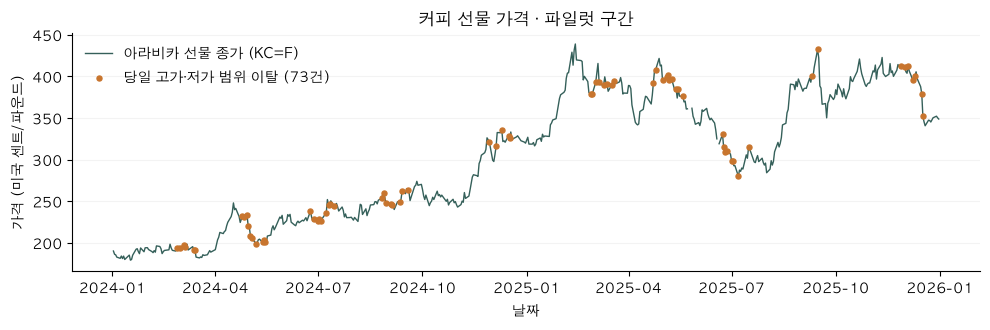

In [5]:
coffee = tables["coffee"]
outside = (coffee.close < coffee.low) | (coffee.close > coffee.high)

fig, ax = plt.subplots(figsize=(10, 3.4), dpi=100)
ax.plot(coffee.date, coffee.close, color="#35605a", linewidth=1, label="아라비카 선물 종가 (KC=F)")
ax.scatter(coffee.loc[outside, "date"], coffee.loc[outside, "close"],
           color="#c8752e", s=13, label=f"당일 고가·저가 범위 이탈 ({outside.sum()}건)", zorder=3)
ax.set(title="커피 선물 가격 · 파일럿 구간", ylabel="가격 (미국 센트/파운드)", xlabel="날짜")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.15)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

In [6]:
examples = coffee.loc[outside, ["date", "open", "high", "low", "close", "volume"]].copy()
examples["gap"] = np.where(examples.close < examples.low,
                           examples.close - examples.low, examples.close - examples.high)
examples = examples.loc[examples.gap.abs().nlargest(5).index].sort_values("date")
numeric_columns = examples.select_dtypes(include="number").columns
examples[numeric_columns] = examples[numeric_columns].round(4)
display(examples.rename(columns={
    "date": "날짜", "open": "시가", "high": "고가", "low": "저가", "close": "종가",
    "volume": "거래량", "gap": "고가·저가 범위 초과분",
}))

,날짜,시가,고가,저가,종가,거래량,고가·저가 범위 초과분
84,2024-05-02,218.00,218.00,218.00,208.65,9.0,-9.35
237,2024-12-10,343.85,347.35,343.70,335.65,24.0,-8.05
295,2025-03-06,413.45,413.45,409.50,393.00,4.0,-16.50
302,2025-03-17,382.75,382.75,382.75,389.35,12.0,6.60
430,2025-09-15,422.90,425.15,422.90,432.35,24.0,7.20


다음에는 과거 Close 피처로 CatBoost와 단순 기준 모델을 비교한다.
이 notebook에서는 학습이나 평가 구간 튜닝을 하지 않았다.